## Notch experiments: do not run, outdated methods 

In [11]:
# Import modules:
from beam_manager import open_beam_library, sublibrary
from bridge_manager_reinoud import Bridge

import numpy as np
import matplotlib.pyplot as plt

In [12]:
# Initiation: load beam library, select beams for experiment and set parameters.
library = open_beam_library('notch8_single.json')
selection = ['A1', 'B1', 'C1']
lib = sublibrary(selection, library)

R_ref = 50 # Ohm
U_in = 10 # V

f_arr = np.logspace(2, 5, 1000)
w_arr = 2*np.pi*f_arr

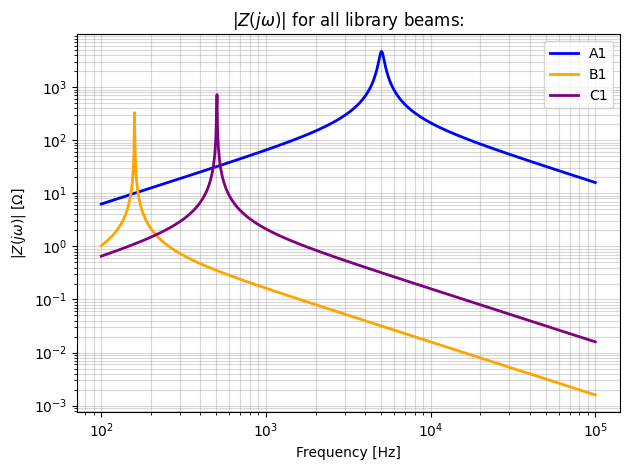

In [13]:
# We should take a proper look at each individual beam impedance:
fig, ax = plt.subplots()
colors = ['blue', 'orange', 'purple']

for key, color in zip(list(lib.keys()), colors):
    
    y = lib[key].admittance(w_arr)
    z_abs = 1 / np.abs(y)

    ax.loglog(f_arr, z_abs, color=color, label=key, linewidth=2)

ax.grid(True, which="both", ls="-", alpha=0.5)
ax.set_ylabel(r'$|Z(j\omega)|$ [$\Omega$]')
ax.set_xlabel('Frequency [Hz]')
ax.legend(loc='upper right')
plt.title(r'$|Z(j\omega)|$ for all library beams:')
plt.tight_layout()
plt.show()

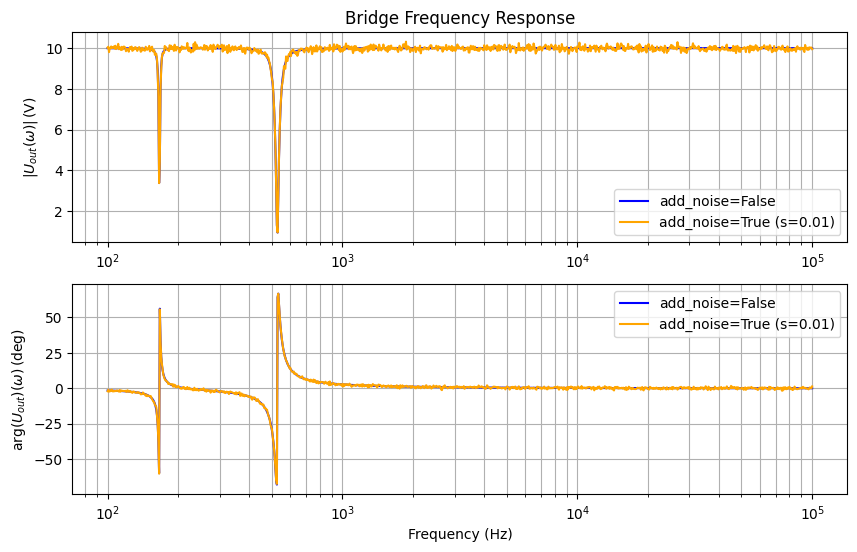

In [14]:
# Experiment 1.1: triangle frequency response WITH NOISE:

# Try to build a triangle with A in the floor, B inclined at the left and a C at the right (unchanged):
topology = [(0, 2), (0, 1), (1, 2)]
struc = Bridge()
struc.construct(lib, topology)

# Solve for bridge frequency response, but let the solver add noise to U_out:
# Initialize RNG:
rng = np.random.default_rng(seed=42)
sigma = 0.01

# Run simulation with and without noise:
U_arr = np.array([struc.solve_U(w, U_in, R_ref, add_noise = False) for w in w_arr]).T
U_out_arr = U_arr[-1,:]
U_mag = np.abs(U_out_arr)
U_phase = np.angle(U_out_arr)

U_arr_noise = np.array([struc.solve_U(w, U_in, R_ref, add_noise = True, sigma=sigma, rng=rng) for w in w_arr]).T
U_out_arr_noise = U_arr_noise[-1,:]
U_mag_noise = np.abs(U_out_arr_noise)
U_phase_noise = np.angle(U_out_arr_noise)

# Plotting:
plt.figure(figsize=(10, 6))

# Plot Magnitude
plt.subplot(2, 1, 1)
plt.semilogx(f_arr, U_mag, color='blue', label = 'add_noise=False')
plt.semilogx(f_arr, U_mag_noise, color='orange', label = f'add_noise=True (s={sigma})')
plt.ylabel(r'$|U_{out}(\omega)|\,(\text{V})$')
plt.grid(True, which="both")
plt.legend()
plt.title('Bridge Frequency Response')

# Plot Phase:
plt.subplot(2, 1, 2)
plt.semilogx(f_arr, np.degrees(U_phase), color='blue', label = 'add_noise=False')
plt.semilogx(f_arr, np.degrees(U_phase_noise), color='orange', label = f'add_noise=True (s={sigma})')
plt.ylabel(r'$\text{arg}(U_{out})(\omega)\,(\text{deg})$')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", ls="-")
plt.legend()

[7986.35556953  983.84065363 1801.56540211]


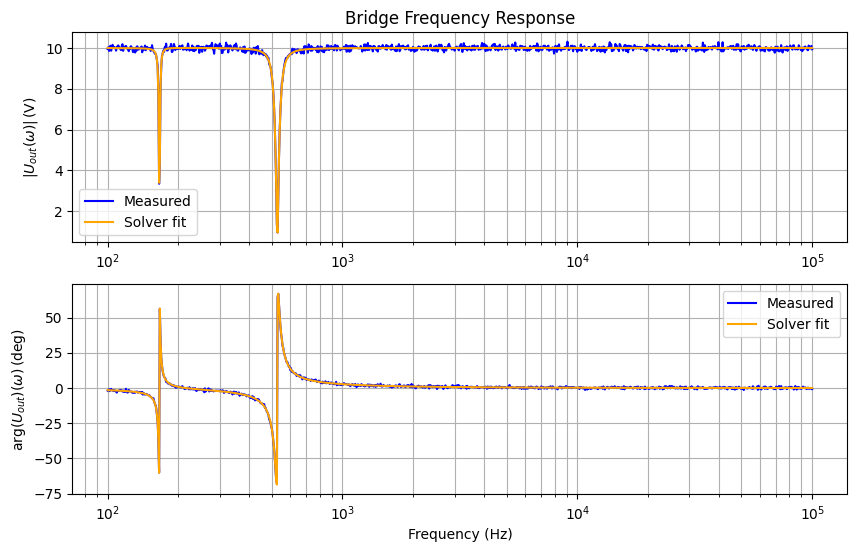

In [15]:
# Experiment 1.2: recover R values for deformed triangle WITH NOISE:

# Let's pretend no deformation in A, but elongation in both B and C:
R_deformed = [4500.0, 1000.0, 2100.0] # 10 % increase for both B and C resistance.

# The measured response (with noise!) should equal:
U_arr_mes = np.array([struc.solve_U(w, U_in, R_ref, R_vec=R_deformed, 
                                    add_noise = True, sigma=sigma, rng=rng) for w in w_arr]).T
U_out_mes = U_arr_mes[-1,:]

# Let's see what resistances the solver predicts:
R_pred = struc.predict_R(w_arr, U_in, U_out_mes, R_ref, max_iter=100)
print(R_pred)

# Plotting:
U_out_mag_mes = np.abs(U_out_mes)
U_out_phase_mes = np.angle(U_out_mes)

U_arr_pred = np.array([struc.solve_U(w, U_in, R_ref, R_vec=R_pred) for w in w_arr]).T
U_out_pred = U_arr_pred[-1,:]
U_out_mag_pred = np.abs(U_out_pred)
U_out_phase_pred = np.angle(U_out_pred)

plt.figure(figsize=(10, 6))

# Plot Magnitude
plt.subplot(2, 1, 1)
plt.semilogx(f_arr, U_out_mag_mes, color='blue', label = 'Measured')
plt.semilogx(f_arr, U_out_mag_pred, color='orange', label = f'Solver fit')
plt.ylabel(r'$|U_{out}(\omega)|\,(\text{V})$')
plt.grid(True, which="both")
plt.legend()
plt.title('Bridge Frequency Response')

# Plot Phase:
plt.subplot(2, 1, 2)
plt.semilogx(f_arr, np.degrees(U_out_phase_mes), color='blue', label = 'Measured')
plt.semilogx(f_arr, np.degrees(U_out_phase_pred), color='orange', label = f'Solver fit')
plt.ylabel(r'$\text{arg}(U_{out})(\omega)\,(\text{deg})$')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", ls="-")
plt.legend()


De noise kan een beetje worden verheven door de Rref lager te hebben en de Za en Zb minder elkaar te laten interfereren.

De max_iter is bij een driehoek goed genoeg op 200

De cost coarse zou ervoor zorgen dat het computeren sneller gebeurt en minder precies is. Maar dat het minder precies is is nu nog niet te merken.

Om in de bridge frequency response unieke pieken te krijgen voor elke beam (Dan is er minder interference). Moet de notch zo spits mogelijk zijn. Dit heeft als nadeel dat op de resonantiefrequentie van de ene beam, alle andere een lage impedantie heeft. In de formule: ZaZb/Za+Zb = 0. Waardoor je dus niks meer ziet in de frequency response (Er loopt geen stroom meer doorheen). Dit kunnen we weer verhelpen door ook een lage Rref in te stellen. Maar als hij te klein is breekt hij onder noise.
